# CellPhoneDB visualization - minimal code

**Purpose**: Create the figure with bubble sizes large enough for editing in Illustrator.

**Figure size**: 120 mm x 60 mm (standard size for Illustrator)

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/scRNA_analysis')

Mounted at /content/drive


## 2. Import packages

In [ ]:
# Install required packages
!pip install -q scanpy numpy pandas leidenalg harmonypy ktplotspy
print('Package installation complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 119.0 MB/s eta 0:00:00
パッケージのインストールが完了しました


In [ ]:
import pandas as pd
import scanpy as sc
import ktplotspy as kpy
import matplotlib.pyplot as plt
import os
import numpy as np


## 3. Parameter settings

**Edit the parameters below as needed.**

In [ ]:
# ==========================================
# Configuration section (edit as needed)
# ==========================================

# --- File paths ---
ADATA_PATH = '/content/drive/MyDrive/scRNA_analysis/Results_0-1m/Meta_Mix_CPDB_7d_selected.h5ad'
MEANS_PATH = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_means_timecourse_7d.txt'
PVALS_PATH = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_pvalues_timecourse_7d.txt'
INTERACTION_SCORES_PATH = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_interaction_scores_timecourse_7d.txt'
OUTPUT_DIR = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2'

# --- Analysis parameters ---
TIMEPOINT = "7d"
GENES = ["COL3A1"]
CELL_TYPE1 = "timecourse_7d_Astro-NT_1|timecourse_7d_Astro-NT_2|timecourse_7d_Astro-NT_3|timecourse_7d_Astro-NT_5|timecourse_7d_Astro-NT_6"
CELL_TYPE2 = "timecourse_7d_VLMC_1|timecourse_7d_ABC_1|timecourse_7d_ABC_2"

# --- Figure size and bubble size ---
# 120 mm x 60 mm = 4.72 x 2.36 inches (for Illustrator)
FIG_WIDTH_INCH = 4.72
FIG_HEIGHT_INCH = 2.36
MAX_BUBBLE_SIZE = 9      # maximum bubble size (default: 6)
HIGHLIGHT_SIZE = 1.5      # size multiplier for significant interactions (default: 0.75)
MIN_INTERACTION_SCORE = 20

print("✓ Parameters set")
print(f"  Figure size: {FIG_WIDTH_INCH} x {FIG_HEIGHT_INCH} inches")
print(f"  Max bubble size: {MAX_BUBBLE_SIZE}")

✓ Parameters set
  Figure size: 4.72 x 2.36 inches
  Max bubble size: 9


## 4. Load data

In [ ]:
# ==========================================
# 📝 Configuration section
# ==========================================

# --- File paths ---
ADATA_PATH = '/content/drive/MyDrive/scRNA_analysis/Results_0-1m/Meta_Mix_CPDB_7d_selected.h5ad'
MEANS_PATH = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_means_timecourse_7d.txt'
PVALS_PATH = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_pvalues_timecourse_7d.txt'
INTERACTION_SCORES_PATH = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_interaction_scores_timecourse_7d.txt'
OUTPUT_DIR = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2'

# --- Analysis parameters ---
TIMEPOINT = "7d"
GENES = ["COL3A1"]  # gene(s) to visualize

# --- Cell types (direction: VLMC/ABC -> Astrocyte) ---
# LIGAND_CELLS = ligand-producing side (VLMC/ABC)
# RECEPTOR_CELLS = receptor side (Astrocyte) <- the cells being affected
LIGAND_CELLS = "timecourse_7d_VLMC_1|timecourse_7d_ABC_1|timecourse_7d_ABC_2"
RECEPTOR_CELLS = "timecourse_7d_Astro-NT_1|timecourse_7d_Astro-NT_2|timecourse_7d_Astro-NT_3|timecourse_7d_Astro-NT_4|timecourse_7d_Astro-NT_5|timecourse_7d_Astro-NT_6"

# --- Figure parameters ---
FIG_WIDTH_INCH = 3.5
FIG_HEIGHT_INCH = 1.8
MAX_BUBBLE_SIZE = 5      # maximum bubble size (default: 6)
HIGHLIGHT_SIZE = 0.8      # size multiplier for significant interactions (default: 0.75)
MIN_INTERACTION_SCORE = 1

# --- Output file name ---
OUTPUT_PREFIX = "VLMC-to-Astro"

print('✓ Parameters set')
print(f'  Direction: VLMC/ABC -> Astrocyte (astrocytes are the affected cells)')
print(f'  Genes: {", ".join(GENES)}')
print(f'  Figure size: {FIG_WIDTH_INCH} x {FIG_HEIGHT_INCH} inch')

✓ パラメータ設定完了
  方向: VLMC/ABC → Astrocyte (アストロサイトが影響を受ける)
  遺伝子: COL3A1
  図サイズ: 3.5 x 1.8 inch


In [ ]:
print('Loading data...')

# Load adata
adata = sc.read_h5ad(ADATA_PATH)
print(f'✓ adata: {adata.shape}')

# Load CellPhoneDB results
means = pd.read_csv(MEANS_PATH, delimiter='\t')
pvals = pd.read_csv(PVALS_PATH, delimiter='\t')
interaction_scores = pd.read_csv(INTERACTION_SCORES_PATH, delimiter='\t')
print(f'✓ CellPhoneDB results loaded')

データ読み込み中...
✓ adata: (18259, 17215)


/tmp/ipython-input-5238/4227239057.py:8: DtypeWarning: Columns (4,12) have mixed types. Specify dtype option on import or set low_memory=False.
/tmp/ipython-input-5238/4227239057.py:9: DtypeWarning: Columns (4,12) have mixed types. Specify dtype option on import or set low_memory=False.


✓ CellPhoneDB結果読み込み完了


/tmp/ipython-input-5238/4227239057.py:10: DtypeWarning: Columns (4,12) have mixed types. Specify dtype option on import or set low_memory=False.


## Step 5: Data cleaning

In [ ]:
print('Cleaning data...')

def identify_metadata_cols(df):
    """Identify metadata columns."""
    metadata_cols = []
    for col in df.columns:
        if '|' in str(col):
            break
        metadata_cols.append(col)
    return metadata_cols

def clean_cpdb_dataframe(df, fill_value=0):
    """Clean a CellPhoneDB result DataFrame."""
    metadata_cols = identify_metadata_cols(df)
    metadata = df[metadata_cols].copy()
    numeric = df.drop(columns=metadata_cols).apply(pd.to_numeric, errors='coerce').fillna(fill_value)
    return pd.concat([metadata, numeric], axis=1)

# Run cleaning
means_clean = clean_cpdb_dataframe(means, fill_value=0)
pvals_clean = clean_cpdb_dataframe(pvals, fill_value=1)
interaction_scores_clean = clean_cpdb_dataframe(interaction_scores, fill_value=0)

print('✓ Data cleaning complete')

データクリーニング中...
✓ データクリーニング完了


In [ ]:
import re

print('Generating plot...')
print(f'  Direction: VLMC/ABC (ligand) -> Astrocyte (receptor)')
print(f'  Max bubble size: {MAX_BUBBLE_SIZE}')

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Identify metadata columns --- #
# explicitly call identify_metadata_cols (also used inside clean_cpdb_dataframe)
pvals_metadata_cols = identify_metadata_cols(pvals) # identify from pvals (pre-cleaning)
means_metadata_cols = identify_metadata_cols(means) # identify from means (pre-cleaning)
scores_metadata_cols = identify_metadata_cols(interaction_scores) # identify from interaction_scores (pre-cleaning)

# --- Add explicit type conversion (defensive) ---
# Cast the numeric columns of pvals_clean to float
numeric_cols_pvals = [col for col in pvals_clean.columns if col not in pvals_metadata_cols]
for col in numeric_cols_pvals:
    pvals_clean[col] = pd.to_numeric(pvals_clean[col], errors='coerce').fillna(1.0).astype(float)

# Cast the numeric columns of means_clean to float
numeric_cols_means = [col for col in means_clean.columns if col not in means_metadata_cols]
for col in numeric_cols_means:
    means_clean[col] = pd.to_numeric(means_clean[col], errors='coerce').fillna(0.0).astype(float)

# Cast the numeric columns of interaction_scores_clean to float
numeric_cols_interaction_scores = [col for col in interaction_scores_clean.columns if col not in scores_metadata_cols]
for col in numeric_cols_interaction_scores:
    interaction_scores_clean[col] = pd.to_numeric(interaction_scores_clean[col], errors='coerce').fillna(0.0).astype(float)
# --- end of type conversion ---

print("Filtering: keeping only interactions in the VLMC/ABC -> Astrocyte direction...")

# Build the list of columns to keep
columns_to_keep = means_metadata_cols.copy() # always keep metadata columns

# Iterate over each interaction column and keep only those matching the defined direction
for col in [c for c in means_clean.columns if c not in means_metadata_cols]:
    parts = col.split('|')
    if len(parts) == 2:
        cell_left = parts[0]  # left-hand cell type (ligand side)
        cell_right = parts[1] # right-hand cell type (receptor side)

        # Allow only direction from LIGAND_CELLS to RECEPTOR_CELLS
        # re.fullmatch requires the entire string to match the pattern
        if re.fullmatch(LIGAND_CELLS, cell_left) and re.fullmatch(RECEPTOR_CELLS, cell_right):
            columns_to_keep.append(col)

# Build the filtered DataFrames
means_clean = means_clean[columns_to_keep].copy()
pvals_clean = pvals_clean[columns_to_keep].copy()
interaction_scores_clean = interaction_scores_clean[columns_to_keep].copy()

print("✓ Filtering complete.")
print(f"  Number of interaction columns in means_clean after filtering: {len([c for c in means_clean.columns if c not in means_metadata_cols])}")
print(f"  First 5 interaction columns in means_clean after filtering: {[c for c in means_clean.columns if c not in means_metadata_cols][:5]}")

# Create the plot
fig = kpy.plot_cpdb(
    adata=adata,
    cell_type1=LIGAND_CELLS,    # ligand-producing side (VLMC/ABC)
    cell_type2=RECEPTOR_CELLS,   # receptor side (Astrocyte) <- the affected side
    means=means_clean,
    pvals=pvals_clean,
    celltype_key="cell_labels",
    genes=GENES,
    figsize=(FIG_WIDTH_INCH, FIG_HEIGHT_INCH),
    title=f"{', '.join(GENES)}: VLMC/ABC → Astrocyte ({TIMEPOINT})",
    max_size=MAX_BUBBLE_SIZE,
    highlight_size=HIGHLIGHT_SIZE,
    degs_analysis=False,
    standard_scale=True,
    interaction_scores=interaction_scores_clean,
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=MIN_INTERACTION_SCORE,
)

print('✓ Plot generated')

プロット生成中...
  方向: VLMC/ABC (リガンド) → Astrocyte (レセプター)
  バブル最大サイズ: 5
フィルタリング中: 特定の相互作用方向 (VLMC/ABC -> Astrocyte) のみ表示します...
✓ フィルタリング完了。
  フィルタリング後のmeans_cleanの相互作用カラム数: 15
  フィルタリング後のmeans_cleanの最初の5つの相互作用カラム: ['timecourse_7d_ABC_1|timecourse_7d_Astro-NT_1', 'timecourse_7d_ABC_1|timecourse_7d_Astro-NT_2', 'timecourse_7d_ABC_1|timecourse_7d_Astro-NT_3', 'timecourse_7d_ABC_1|timecourse_7d_Astro-NT_5', 'timecourse_7d_ABC_1|timecourse_7d_Astro-NT_6']
✓ プロット生成完了


## Step 7: Save

In [ ]:
                                                                                                                                                                                                            if fig:
    gene_str = "_".join(GENES)
    svg_path = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_{TIMEPOINT}_{gene_str}.svg")
    png_path = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_{TIMEPOINT}_{gene_str}.png")

    # Save
    fig.save(svg_path, format="svg", dpi=300)
    fig.save(png_path, format="png", dpi=300)

    print('✓ Saved:')
    print(f'  SVG: {svg_path}')
    print(f'  PNG: {png_path}')
    print('\nReady for editing in Illustrator.')

    plt.close()
else:
    print('✗ Error: plot was not generated')

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3.5 x 1.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/VLMC-to-Astro_7d_COL3A1.svg
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3.5 x 1.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/VLMC-to-Astro_7d_COL3A1.png


✓ 保存完了:
  SVG: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/VLMC-to-Astro_7d_COL3A1.svg
  PNG: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/VLMC-to-Astro_7d_COL3A1.png

イラストレーターで編集できます!


Astroフィルタ後のデータ数: 39
動的に計算された図のサイズ: 7.50 x 1.80 インチ


/tmp/ipython-input-5238/3763465723.py:131: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


✓ Plot saved:
  SVG: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/bubble_plot_custom_7d_COL3A1.svg
  PNG: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/bubble_plot_custom_7d_COL3A1.png


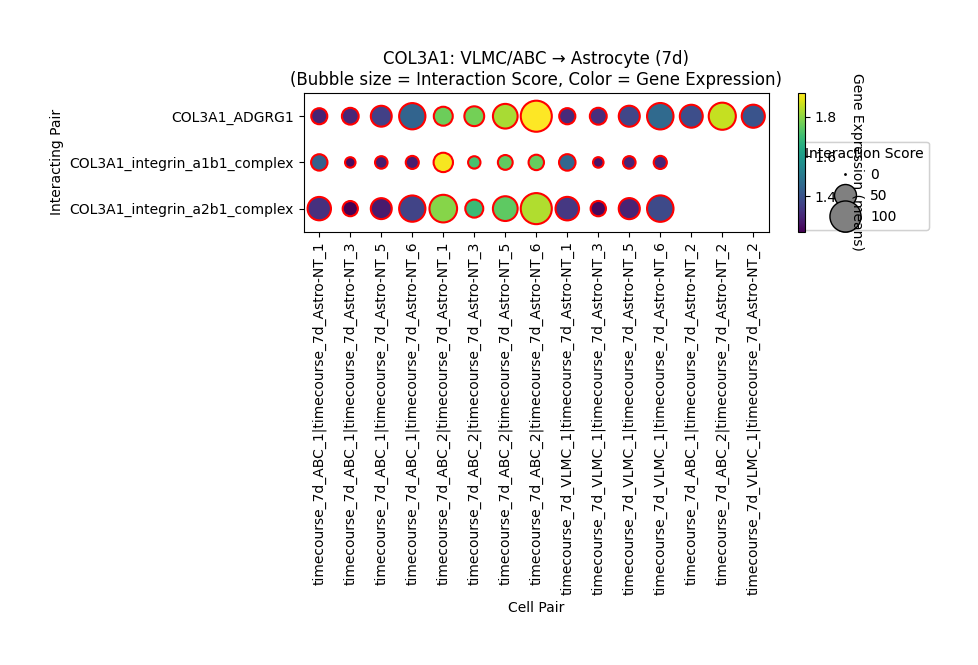

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Convert to long format
data_list = []
interaction_cols = [c for c in means_clean.columns if c not in means_metadata_cols]

for idx, row in means_clean.iterrows():
    interacting_pair = row['interacting_pair']
    for col in interaction_cols:
        cell_pair = col
        mean_val = means_clean.loc[idx, col]
        score_val = interaction_scores_clean.loc[idx, col]
        pval = pvals_clean.loc[idx, col]

        if pval < 0.05 and score_val >= MIN_INTERACTION_SCORE:  # filter
            data_list.append({
                'interacting_pair': interacting_pair,
                'cell_pair': cell_pair,
                'mean_expression': mean_val,
                'interaction_score': score_val,
                'pval': pval
            })

df_plot = pd.DataFrame(data_list)

# Filter df_plot to include only interacting_pairs related to GENES
if GENES:
    gene_pattern = '|'.join(GENES) # Create a regex pattern like 'GENE1|GENE2'
    df_plot = df_plot[df_plot['interacting_pair'].str.contains(gene_pattern, case=False, na=False)]

TARGET_ASTRO = ["Astro-NT_1", "Astro-NT_2", "Astro-NT_3", "Astro-NT_5", "Astro-NT_6"]
astro_pattern = '|'.join(TARGET_ASTRO)
df_plot = df_plot[df_plot['cell_pair'].str.contains(astro_pattern, case=False, na=False)]
print(f"Number of rows after Astro filter: {len(df_plot)}")
# edge color for significant bubbles
df_plot['edge_colors'] = np.where(df_plot['pval'] < 0.05, 'red', 'black')

# Dynamically compute figure size
num_x_labels = len(df_plot['cell_pair'].unique())
num_y_labels = len(df_plot['interacting_pair'].unique())

# Base size (e.g., 0.5 inch per label)
base_width_per_label = 0.5
base_height_per_label = 0.5

# Set minimum and maximum sizes (adjust as needed)
min_fig_width = 3.5
max_fig_width = 15.0
min_fig_height = 1.8
max_fig_height = 10.0

# Clamp the computed width and height to the configured min/max range
dynamic_fig_width = max(min_fig_width, min(max_fig_width, num_x_labels * base_width_per_label))
dynamic_fig_height = max(min_fig_height, min(max_fig_height, num_y_labels * base_height_per_label))

print(f"Dynamically computed figure size: {dynamic_fig_width:.2f} x {dynamic_fig_height:.2f} inches")

# Create the plot
fig, ax = plt.subplots(figsize=(dynamic_fig_width, dynamic_fig_height))

scatter = ax.scatter(
    x=df_plot['cell_pair'],  # cell pair on the x-axis
    y=df_plot['interacting_pair'],  # interacting pair (pathway) on the y-axis
    s=df_plot['interaction_score'] * MAX_BUBBLE_SIZE,  # size = score
    c=df_plot['mean_expression'],  # color = mean expression
    cmap='viridis',  # use viridis without reversing (high = blue, low = yellow)
    alpha=1.0,  # fixed alpha (fully opaque)
    edgecolors=df_plot['edge_colors'], # edge color for significant bubbles
    linewidth=1.5
)

# Extend x- and y-axis ranges so bubbles aren't clipped
ax.set_xlim(-0.5, num_x_labels - 0.5)
ax.set_ylim(-0.5, num_y_labels - 0.5)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Gene Expression (means)', rotation=270, labelpad=20)

# Add a size legend
# Get the range of interaction_score actually plotted
min_score = df_plot['interaction_score'].min()
max_score = df_plot['interaction_score'].max()

# Representative score values (e.g., near min, middle, max)
# Adjust the number of legend entries when scores are small
if max_score > 0:
    legend_scores_raw = np.linspace(0, max_score, 3) # split 0..max_score into 3
    legend_scores_raw = np.round(legend_scores_raw).astype(int) # round to integers
    # ensure values are unique to avoid duplicates
    legend_scores_raw = np.unique(legend_scores_raw)

    # ensure at least two legend points (e.g., 0 and max)
    if len(legend_scores_raw) < 2 and max_score > 0:
        legend_scores_raw = np.array([0, max_score])
    elif len(legend_scores_raw) == 0 and max_score == 0:
        legend_scores_raw = np.array([0]) # all-zero case
    elif len(legend_scores_raw) == 1 and legend_scores_raw[0] == 0 and max_score > 0: # only got 0
        legend_scores_raw = np.array([0, max_score])
else: # if max_score <= 0, legend is just 0
    legend_scores_raw = np.array([0])


legend_scores_to_plot = sorted(list(set(legend_scores_raw)))

legend_handles = []
for score_val in legend_scores_to_plot:
    size = score_val * MAX_BUBBLE_SIZE
    # if size is 0, set a minimum so the legend bubble doesn't completely disappear
    display_size = max(size, 1) if score_val > 0 else 1 # also show a bubble for zero score
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                                     markeredgecolor='black', markersize=np.sqrt(display_size),
                                     label=f'{score_val:.0f}'))

# Display the legend
legend_size = ax.legend(handles=legend_handles, title='Interaction Score', loc='upper left', bbox_to_anchor=(1.05, 0.7))
ax.add_artist(legend_size) # needed to add a new legend on top of any existing one


# Axis labels etc.
ax.set_xlabel('Cell Pair')  # set x-axis label to 'Cell Pair'
ax.set_ylabel('Interacting Pair')  # set y-axis label to 'Interacting Pair (Pathway)'
ax.set_title(f"{', '.join(GENES)}: VLMC/ABC → Astrocyte ({TIMEPOINT})\n(Bubble size = Interaction Score, Color = Gene Expression)")

# Rotate x-axis labels if they overlap
plt.xticks(rotation=90)

plt.tight_layout()

# Set output file paths (reusing png_path and svg_path)
gene_str = "_".join(GENES)
svg_path = os.path.join(OUTPUT_DIR, f"bubble_plot_custom_{TIMEPOINT}_{gene_str}.svg")
png_path = os.path.join(OUTPUT_DIR, f"bubble_plot_custom_{TIMEPOINT}_{gene_str}.png")

plt.savefig(svg_path, format="svg", dpi=300)
plt.savefig(png_path, format="png", dpi=300)

print(f"✓ Plot saved:")
print(f"  SVG: {svg_path}")
print(f"  PNG: {png_path}")

plt.show()

---

## Appendix: Other size presets

If you want to change the figure size, refer to the presets below:

```python
# 120 mm x 60 mm (standard)
FIG_WIDTH_INCH = 4.72
FIG_HEIGHT_INCH = 2.36

# 150 mm x 75 mm (large)
FIG_WIDTH_INCH = 5.91
FIG_HEIGHT_INCH = 2.95

# 180 mm x 90 mm (extra large)
FIG_WIDTH_INCH = 7.09
FIG_HEIGHT_INCH = 3.54

# square 120 mm x 120 mm
FIG_WIDTH_INCH = 4.72
FIG_HEIGHT_INCH = 4.72
```

/tmp/ipython-input-1827/2841883286.py:27: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
/tmp/ipython-input-1827/2841883286.py:27: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
/tmp/ipython-input-1827/2841883286.py:27: DtypeWarning: Columns (4,12) have mixed types. Specify dtype option on import or set low_memory=False.
/tmp/ipython-input-1827/2841883286.py:27: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
/tmp/ipython-input-1827/2841883286.py:27: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.


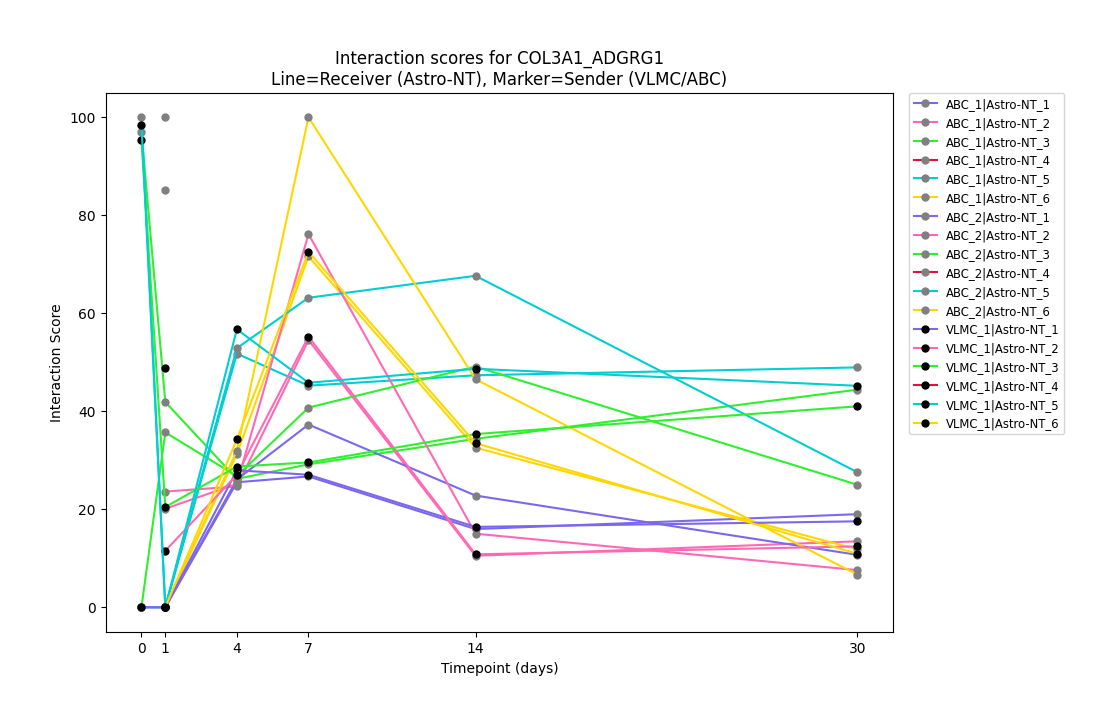

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 🔁 Mapping between timepoint label and day_num
day_files = {
    "0d": 0,
    "1d": 1,
    "4d": 4,
    "7d": 7,
    "14d": 14,
    "1m": 30
}

all_scores = []

# ✅ Cell types
astro_types = ["Astro-NT_1", "Astro-NT_2", "Astro-NT_3", "Astro-NT_4", "Astro-NT_5", "Astro-NT_6"]
sender_types = ["VLMC_1", "ABC_1", "ABC_2"]

# ✅ Regex patterns
pattern_astro = re.compile("(" + "|".join([re.escape(ct) + "$" for ct in astro_types]) + ")")
pattern_sender = re.compile("(" + "|".join([re.escape(ct) + "$" for ct in sender_types]) + ")")

# ✅ Load files
for day_label, day_num in day_files.items():
    df = pd.read_csv(f"/content/drive/MyDrive/scRNA_analysis/figures_Ver2/statistical_analysis_interaction_scores_timecourse_{day_label}.txt", sep="\t")
    score_cols = [col for col in df.columns if "|" in col]
    melted = df.melt(
        id_vars=['interacting_pair', 'gene_a', 'gene_b'],
        value_vars=score_cols,
        var_name='cell_pair',
        value_name='interaction_score'
    )
    melted["day_num"] = day_num
    all_scores.append(melted)

# ✅ Concatenate
long_df = pd.concat(all_scores, ignore_index=True)

# ✅ Select COL3A1_ADGRG1
col3a1_df = long_df[
    (long_df["interacting_pair"] == "COL3A1_ADGRG1") &
    (
        long_df["gene_a"].str.contains("COL3A1", na=False) |
        long_df["gene_b"].str.contains("COL3A1", na=False)
    )
].copy()

# ✅ Keep only sender=VLMC/ABC -> receiver=Astro
def match_cell_pair(cp):
    try:
        if pd.isna(cp) or not isinstance(cp, str) or "|" not in cp:
            return False
        left, right = cp.split("|")
        return (pattern_sender.search(left) and pattern_astro.search(right))
    except:
        return False

mask = col3a1_df["cell_pair"].apply(match_cell_pair)
col3a1_df = col3a1_df[mask.fillna(False).astype(bool)].copy()

# ✅ Extract sender, receiver, and normalized_pair
def extract_sender_receiver(cell_pair):
    left, right = cell_pair.split("|")
    sender = "_".join(left.split("_")[-2:])
    receiver = "_".join(right.split("_")[-2:])
    return sender, receiver

col3a1_df[["sender", "receiver"]] = col3a1_df["cell_pair"].apply(
    lambda x: pd.Series(extract_sender_receiver(x))
)
col3a1_df["normalized_pair"] = col3a1_df["sender"] + "|" + col3a1_df["receiver"]

# ✅ Color settings
receiver_colors = {
    "Astro-NT_1": "#7B68EE",  # Slate Blue
    "Astro-NT_2": "#FF69B4",   # Hot Pink
    "Astro-NT_3": "#2FEF2F",   # Green
    "Astro-NT_4": "#DC143C",   # Crimson
    "Astro-NT_5": "#00CED1",
    "Astro-NT_6": "#FFD700",
}

sender_colors = {
    "VLMC_1": "black",
    "ABC_1": "gray",
    "ABC_2": "gray",
}

# ✅ Plot
fig, ax = plt.subplots(figsize=(21, 7))

for norm_pair, group in col3a1_df.groupby("normalized_pair"):
    group_unique = group.drop_duplicates(subset=["day_num"])
    grouped = group_unique.sort_values("day_num")

    receiver = group["receiver"].iloc[0]
    sender = group["sender"].iloc[0]

    line_color = receiver_colors.get(receiver, "black")
    marker_color = sender_colors.get(sender, "black")

    ax.plot(grouped["day_num"], grouped["interaction_score"],
            color=line_color, label=norm_pair, marker='o', linestyle='-',
            markerfacecolor=marker_color, markeredgecolor='none')  # ★no edge

ax.set_title("Interaction scores for COL3A1_ADGRG1\nLine=Receiver (Astro-NT), Marker=Sender (VLMC/ABC)")
ax.set_xlabel("Timepoint (days)")
ax.set_ylabel("Interaction Score")
ax.set_xticks(sorted(col3a1_df["day_num"].unique()))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize='small', borderaxespad=0.)
fig.subplots_adjust(right=0.5)

plt.savefig("COL3A1_ADGRG1_interaction_scores_sender_receiver_colored_noedge.svg", format="svg")
plt.show()

Astro-NT内での割合確認（day_numごとに合計1.0になるはず）:
day_num
0     1.0
1     1.0
4     1.0
7     1.0
14    1.0
30    1.0
Name: proportion, dtype: float64


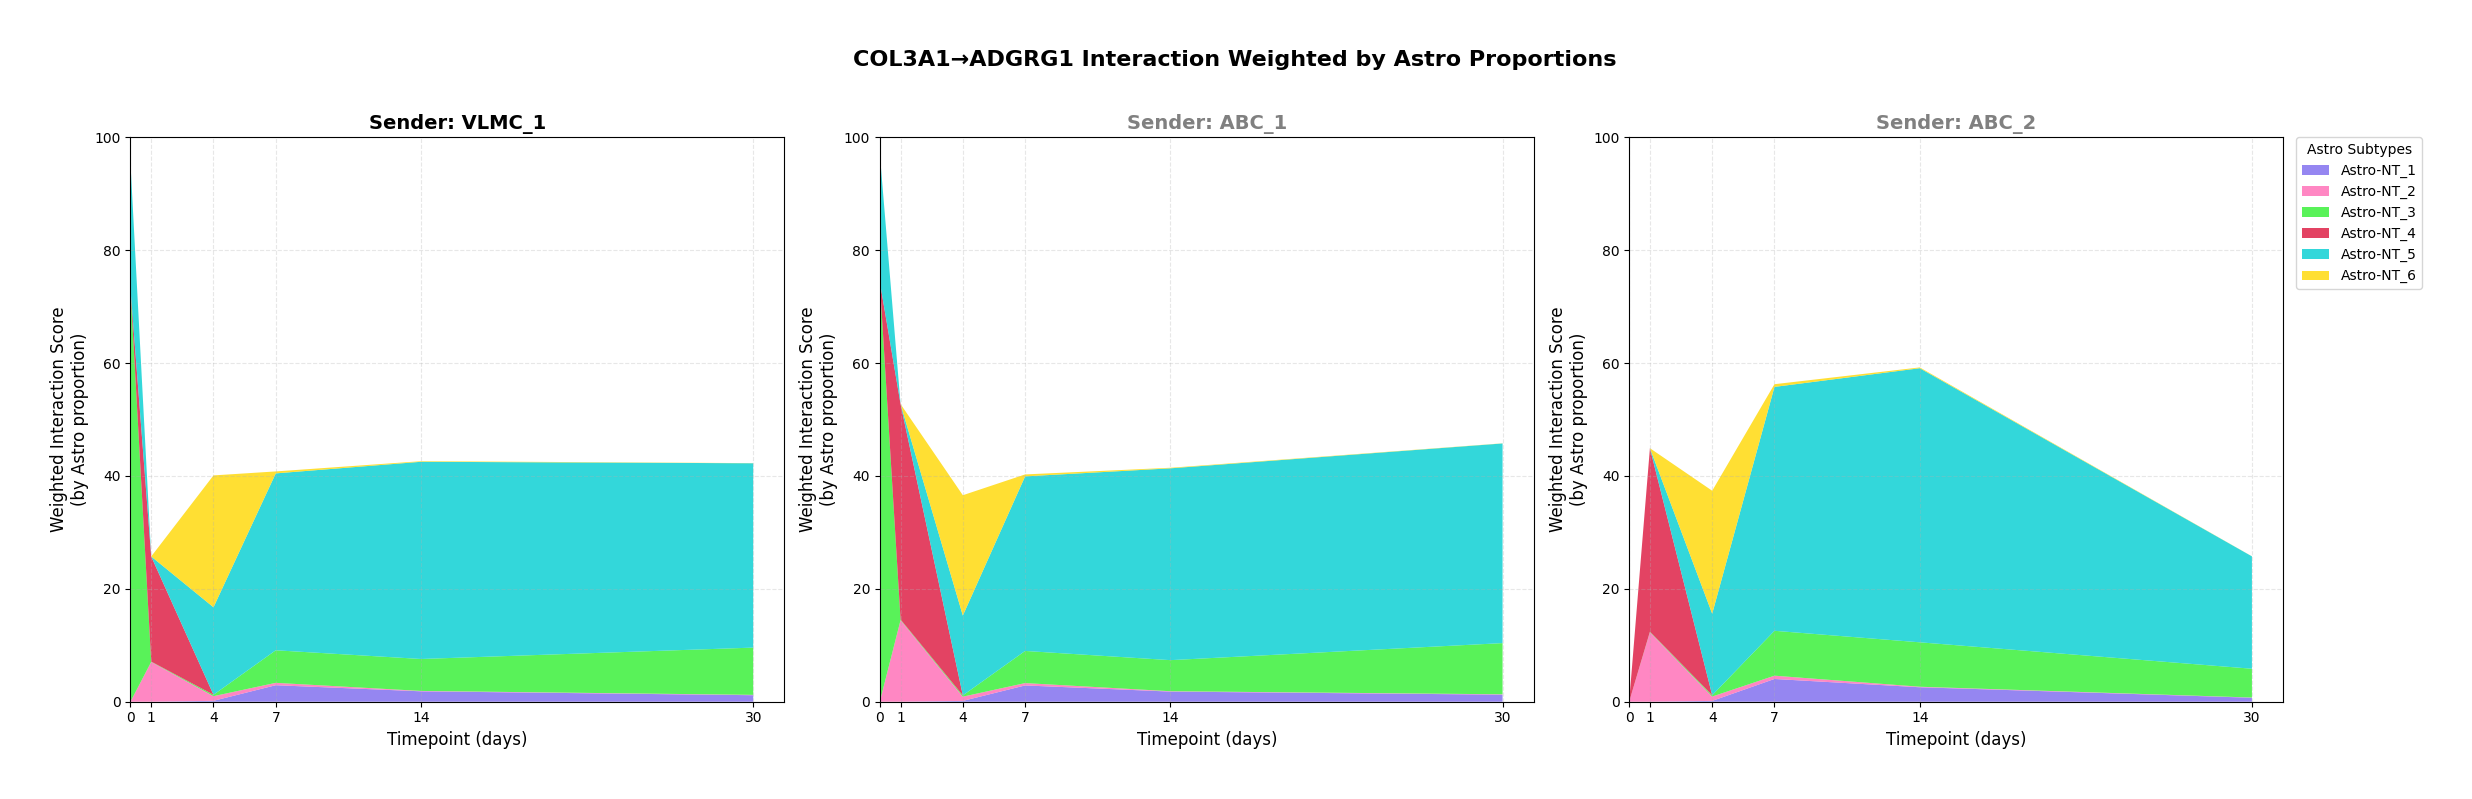

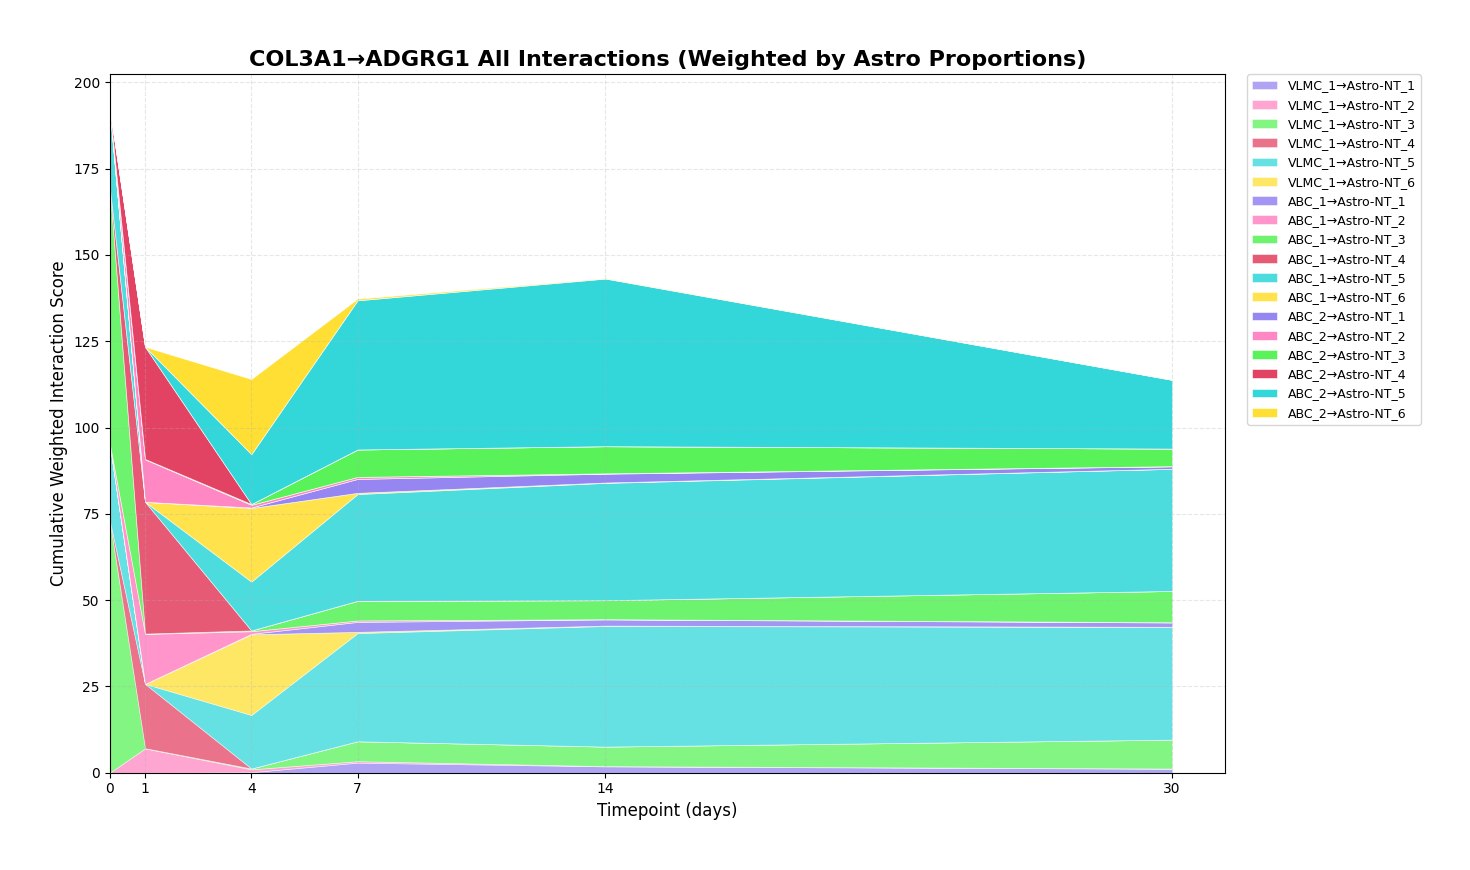


重み付けスコアの統計:
day_num                   0          1          4          7          14  \
sender receiver                                                            
ABC_1  Astro-NT_1   0.000000   0.000000   0.144324   2.885555   1.793843   
       Astro-NT_2   0.000000  14.465816   0.753280   0.417278   0.064721   
       Astro-NT_3  74.423614   0.098068   0.222394   5.692674   5.507994   
       Astro-NT_4   0.000000  38.173302   0.000000   0.000000   0.000000   
       Astro-NT_5  22.704715   0.000000  14.146679  30.935211  33.987125   
       Astro-NT_6   0.000000   0.000000  21.321067   0.342517   0.100361   
ABC_2  Astro-NT_1   0.000000   0.000000   0.147453   4.030910   2.563211   
       Astro-NT_2   0.000000  12.321007   0.769599   0.582905   0.092481   
       Astro-NT_3   0.000000   0.083529   0.227216   7.952291   7.870348   
       Astro-NT_4   0.000000  32.514492   0.000000   0.000000   0.000000   
       Astro-NT_5   0.000000   0.000000  14.453372  43.214737  48.564524   

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import re
import os

save_dir = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2'
os.makedirs(save_dir, exist_ok=True)

# --- Create cell_counts DataFrame (missing in previous execution) ---
# Load the full adata object containing all timepoints and cell_labels
# This path should point to the adata saved after humanization and cell labeling (e.g., in IspFubj4Fo3B)
full_adata_path = '/content/drive/MyDrive/scRNA_analysis/Results_0-1m/Meta_Mix_CPDB.h5ad'
adata_full = sc.read(full_adata_path)

# Ensure 'batch' and 'cell_labels' are available in adata_full.obs
if 'batch' not in adata_full.obs.columns or 'cell_labels' not in adata_full.obs.columns:
    raise ValueError("Missing 'batch' or 'cell_labels' in adata_full.obs for proportion calculation.")

# Extract day_num from the 'batch' column
def extract_day_num_from_batch(batch_name):
    if batch_name.startswith('uninjured'):
        return 0
    match_1d = re.match(r'timecourse_1d_\d+', batch_name)
    if match_1d:
        return 1
    match_4d = re.match(r'timecourse_4d_\d+', batch_name)
    if match_4d:
        return 4
    match_7d = re.match(r'timecourse_7d_\d+', batch_name)
    if match_7d:
        return 7
    match_14d = re.match(r'timecourse_14d_\d+', batch_name)
    if match_14d:
        return 14
    match_1m = re.match(r'timecourse_1m_\d+', batch_name)
    if match_1m:
        return 30
    # Handle cases where other timepoints like 1m, 2m exist but are not part of the analysis day_files
    # For this specific task, we only care about 0d, 1d, 4d, 7d, 14d
    return np.nan

adata_full.obs['day_num'] = adata_full.obs['batch'].apply(extract_day_num_from_batch)

# Filter out rows where day_num could not be mapped (e.g., other timecourses not in day_files)
adata_obs_filtered_for_proportions = adata_full.obs[adata_full.obs['day_num'].notna()].copy()

# Extract simplified_celltype from cell_labels (e.g., 'Astro-NT_3' from 'timecourse_4d_Astro-NT_3')
# This must be consistent with how 'receiver' was extracted in col3a1_df
adata_obs_filtered_for_proportions['simplified_celltype'] = \
    adata_obs_filtered_for_proportions['cell_labels'].apply(lambda x: '_'.join(x.split('_')[-2:]))

# Calculate cell counts per day_num and simplified_celltype
cell_counts_raw = adata_obs_filtered_for_proportions.groupby(['day_num', 'simplified_celltype']).size().reset_index(name='count')

# Calculate total cells per day_num
total_cells_per_day = adata_obs_filtered_for_proportions.groupby('day_num').size().reset_index(name='total_count')

# Merge to calculate proportions
cell_counts = cell_counts_raw.merge(total_cells_per_day, on='day_num')
cell_counts['proportion'] = cell_counts['count'] / cell_counts['total_count']

# Filter for Astro-NT types as these are the receiver cells in this context
cell_counts = cell_counts[cell_counts['simplified_celltype'].str.startswith('Astro-NT')].copy()

astro_total_per_day = cell_counts.groupby('day_num')['count'].transform('sum')
cell_counts['proportion'] = cell_counts['count'] / astro_total_per_day
# =====================

print("Check Astro-NT proportions (sum per day_num should be 1.0):")
print(cell_counts.groupby('day_num')['proportion'].sum())

# ✅ Weight by Astro-side proportions
col3a1_weighted = col3a1_df.copy()

# Merge in the receiver proportions
receiver_props = cell_counts[['day_num', 'simplified_celltype', 'proportion']].rename(
    columns={'simplified_celltype': 'receiver', 'proportion': 'receiver_proportion'}
)
col3a1_weighted = col3a1_weighted.merge(receiver_props, on=['day_num', 'receiver'], how='left')

# Compute weighted score
col3a1_weighted['weighted_score'] = col3a1_weighted['interaction_score'] * col3a1_weighted['receiver_proportion']

# ✅ Build pivot tables (per sender)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for idx, sender in enumerate(sender_types):
    ax = axes[idx]

    # Extract data for this sender
    sender_data = col3a1_weighted[col3a1_weighted['sender'] == sender].copy()

    # Pivot: day_num x receiver (Astro subtypes)
    pivot = sender_data.pivot_table(
        index='day_num',
        columns='receiver',
        values='weighted_score',
        aggfunc='mean'  # average if the same combination occurs multiple times
    ).fillna(0)

    # Fix the order of Astro subtypes
    astro_order = [a for a in astro_types if a in pivot.columns]
    pivot = pivot[astro_order]

    # Check if pivot has columns before plotting
    if not pivot.empty and not pivot.columns.empty: # Add this check
        # Stacked area chart
        ax.stackplot(
            pivot.index,
            *[pivot[col] for col in pivot.columns],
            labels=pivot.columns,
            colors=[receiver_colors[col] for col in pivot.columns],
            alpha=0.8
        )

        # Decoration
        sender_color = sender_colors.get(sender, 'black')
        ax.set_title(f'Sender: {sender}', fontsize=14, fontweight='bold', color=sender_color)
        ax.set_xlabel('Timepoint (days)', fontsize=12)
        ax.set_ylabel('Weighted Interaction Score\n(by Astro proportion)', fontsize=12)
        ax.set_xticks(sorted(col3a1_weighted['day_num'].unique()))
        ax.set_xlim(left=0)   # <- added
        ax.set_ylim(0, 100)
        ax.set_ylim(bottom=0) # <- added
        ax.grid(True, alpha=0.3, linestyle='--')

        if idx == 2:
            ax.legend(title='Astro Subtypes', bbox_to_anchor=(1.02, 1),
                     loc="upper left", fontsize=10, borderaxespad=0.)
    else:
        print(f"Skipping plot for sender {sender} (first plot) due to no data.")
        ax.set_title(f'Sender: {sender} (No Data)', fontsize=14, fontweight='bold', color=sender_colors.get(sender, 'black'))
        ax.set_xlabel('Timepoint (days)', fontsize=12)
        ax.set_ylabel('Weighted Interaction Score\n(by Astro proportion)', fontsize=12)

plt.suptitle('COL3A1→ADGRG1 Interaction Weighted by Astro Proportions',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(f"{save_dir}/COL3A1_ADGRG1_stacked_area_by_sender.svg", format="svg", bbox_inches='tight')
plt.show()

# ✅ Option: combined version with all senders in one plot
fig, ax = plt.subplots(figsize=(14, 8))

# Track cumulative baseline for stacked plot
cumulative_baseline = np.zeros(len(sorted(col3a1_weighted['day_num'].unique())))

# Pivot over all data (per sender|receiver combination)
for sender in sender_types:
    sender_data = col3a1_weighted[col3a1_weighted['sender'] == sender].copy()

    pivot = sender_data.pivot_table(
        index='day_num',
        columns='receiver',
        values='weighted_score',
        aggfunc='mean'
    ).fillna(0)

    # Fix the order of Astro subtypes (important for consistent stacking)
    astro_order = [a for a in astro_types if a in pivot.columns]
    pivot = pivot[astro_order]

    # This needs to be done more carefully with all timepoints available in pivot index
    # Ensure pivot index covers all day_num for consistent stacking
    all_day_nums = sorted(col3a1_weighted['day_num'].unique())
    pivot = pivot.reindex(all_day_nums, fill_value=0)

    # Check if pivot has columns before plotting
    if not pivot.empty and not pivot.columns.empty: # Add this check
        # Use a different alpha for each sender
        alpha_val = 0.6 if sender == "VLMC_1" else (0.7 if sender == "ABC_1" else 0.8)

        for col in pivot.columns:
            ax.fill_between(
                pivot.index,
                cumulative_baseline,
                cumulative_baseline + pivot[col].values,
                label=f'{sender}→{col}',
                color=receiver_colors[col],
                alpha=alpha_val,
                edgecolor='white',
                linewidth=0.5
            )
            cumulative_baseline += pivot[col].values # Update cumulative baseline after adding this segment
    else:
        print(f"Skipping plot for sender {sender} (combined plot) due to no data.")
        # Optionally add a dummy label to the legend if no data for this sender
        ax.plot([], [], label=f'{sender} (No Data)', color=sender_colors.get(sender, 'gray'), linestyle='-')

ax.set_xlabel('Timepoint (days)', fontsize=12)
ax.set_ylabel('Cumulative Weighted Interaction Score', fontsize=12)
ax.set_title('COL3A1→ADGRG1 All Interactions (Weighted by Astro Proportions)',
             fontsize=16, fontweight='bold')
ax.set_xticks(sorted(col3a1_weighted['day_num'].unique()))
ax.set_xlim(left=0)   # <- added
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9,
         ncol=1, borderaxespad=0.)
plt.tight_layout()
plt.savefig(f"{save_dir}/COL3A1_ADGRG1_stacked_area_combined.svg", format="svg", bbox_inches='tight')
plt.show()

# ✅ Data check
print("\nWeighted-score statistics:")
print(col3a1_weighted.groupby(['sender', 'receiver', 'day_num'])['weighted_score'].mean().unstack(fill_value=0))

In [ ]:
pip install --user scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 8.0 MB/s eta 0:00:00


In [ ]:
import scanpy as sc
adata = sc.read('/content/drive/MyDrive/scRNA_analysis/Results_0-1m/Meta_Mix_0-1m.h5ad')


In [ ]:
adata

AnnData object with n_obs × n_vars = 126070 × 4084
    obs: 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'leiden_annotation', 'leiden_annotation_simplified', 'dpt_pseudotime', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_annotation_colors', 'leiden_annotation_simplified_colors', 'leiden_annotation_simplified_sizes', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
print(adata.obsm.keys())
# -> shows something like KeysView(['X_pca', 'X_scVI', 'X_umap', ...])

KeysView(AxisArrays with keys: X_diffmap, X_pca, X_umap)


In [ ]:
astro_adata = adata[adata.obs['leiden_annotation_simplified'].str.startswith('Astro-NT_')]

Subset: 7891 cells

--- クラスター分布 ---
leiden_annotation_simplified
Astro-NT_5    3935
Astro-NT_6    1221
Astro-NT_3     912
Astro-NT_2     868
Astro-NT_4     489
Astro-NT_1     466
Name: count, dtype: int64
Root cell: timecourse_14d_8-TCTCCGAGTCCCGCAA (index: 63)


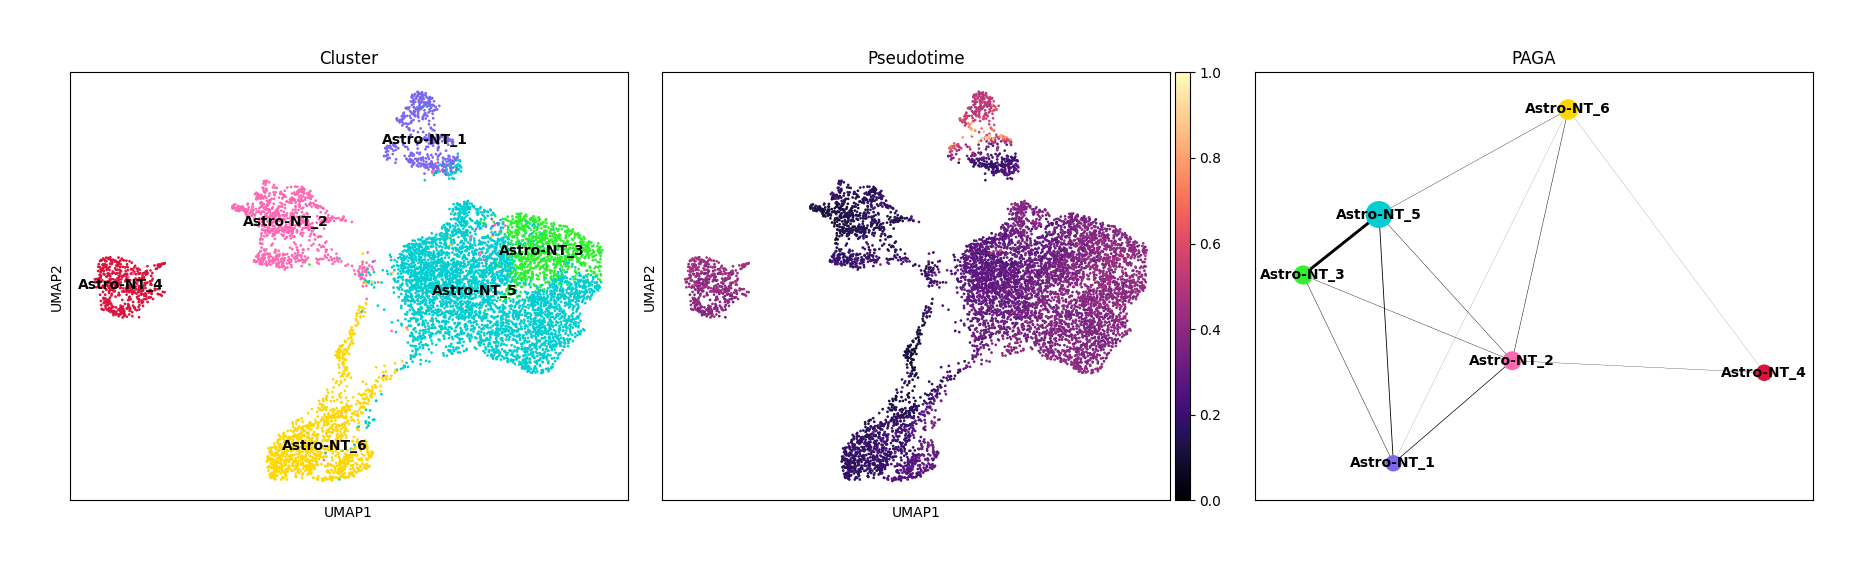

保存完了: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/paga_pseudotime_cluster_injuredOnly_Ver3.svg


In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# Set the output directory
sc.settings.figdir = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2'

# ========== Specify target batches ==========
target_batches = [
    'timecourse_1d_2', 'timecourse_1d_3', 'timecourse_1d_8',
    'timecourse_4d_5', 'timecourse_4d_6', 'timecourse_4d_8',
    'timecourse_7d_4', 'timecourse_7d_9',
    'timecourse_14d_10', 'timecourse_14d_8', 'timecourse_14d_9',
    'timecourse_1m_10', 'timecourse_1m_5', 'timecourse_1m_9',
]

# ========== 1. Build subset ==========
astro_sub = astro_adata[astro_adata.obs['batch'].isin(target_batches)].copy()

# reset any stale iroot
astro_sub.uns.pop('iroot', None)

print(f"Subset: {astro_sub.n_obs} cells")
print("\n--- Cluster distribution ---")
print(astro_sub.obs['leiden_annotation_simplified'].value_counts())

# ========== 2. Skip HVG selection and rerun PCA ==========
sc.pp.scale(astro_sub)
sc.tl.pca(astro_sub, n_comps=30)

# ========== 3. neighbors -> UMAP -> PAGA ==========
sc.pp.neighbors(astro_sub, use_rep="X_pca", n_neighbors=15, n_pcs=30)
sc.tl.umap(astro_sub)
sc.tl.paga(astro_sub, groups="leiden_annotation_simplified")

# ========== 4. Set iroot -> DPT ==========
root_cluster = "Astro-NT_2"

if root_cluster not in astro_sub.obs["leiden_annotation_simplified"].values:
    print(f"WARNING: '{root_cluster}' is not present")
    print("Available:", sorted(astro_sub.obs["leiden_annotation_simplified"].unique().tolist()))
else:
    root_cell_name = astro_sub.obs[
        astro_sub.obs["leiden_annotation_simplified"] == root_cluster
    ].index[0]
    root_index = np.where(astro_sub.obs_names == root_cell_name)[0][0]
    astro_sub.uns['iroot'] = root_index
    print(f"Root cell: {root_cell_name} (index: {root_index})")

    sc.tl.dpt(astro_sub)

    # ========== 5. Three-panel plot ==========
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Cluster UMAP
    sc.pl.umap(
        astro_sub,
        color="leiden_annotation_simplified",
        title="Cluster",
        ax=axes[0],
        show=False,
        legend_loc="on data"
    )

    # Pseudotime UMAP
    sc.pl.umap(
        astro_sub,
        color="dpt_pseudotime",
        title="Pseudotime",
        ax=axes[1],
        show=False,
        color_map="magma",
        vmin=0, vmax=1
    )

    # PAGA
    sc.pl.paga(
    astro_sub,
    color="leiden_annotation_simplified",
    title="PAGA",
    ax=axes[2],
    show=False,
)

    plt.tight_layout()
    fig.savefig(
        f"{sc.settings.figdir}/paga_pseudotime_cluster_injuredOnly_Ver3.svg",
        bbox_inches="tight"
    )
    plt.show()
    print(f"Saved: {sc.settings.figdir}/paga_pseudotime_cluster_injuredOnly_Ver3.svg")

Subset: 7891 cells
leiden_annotation_simplified
Astro-NT_5    3935
Astro-NT_6    1221
Astro-NT_3     912
Astro-NT_2     868
Astro-NT_4     489
Astro-NT_1     466
Name: count, dtype: int64
利用可能なobsm: ['X_diffmap', 'X_pca', 'X_umap']
Root cell: timecourse_14d_10-ATTACCTGTCTTTCAT (index: 1)


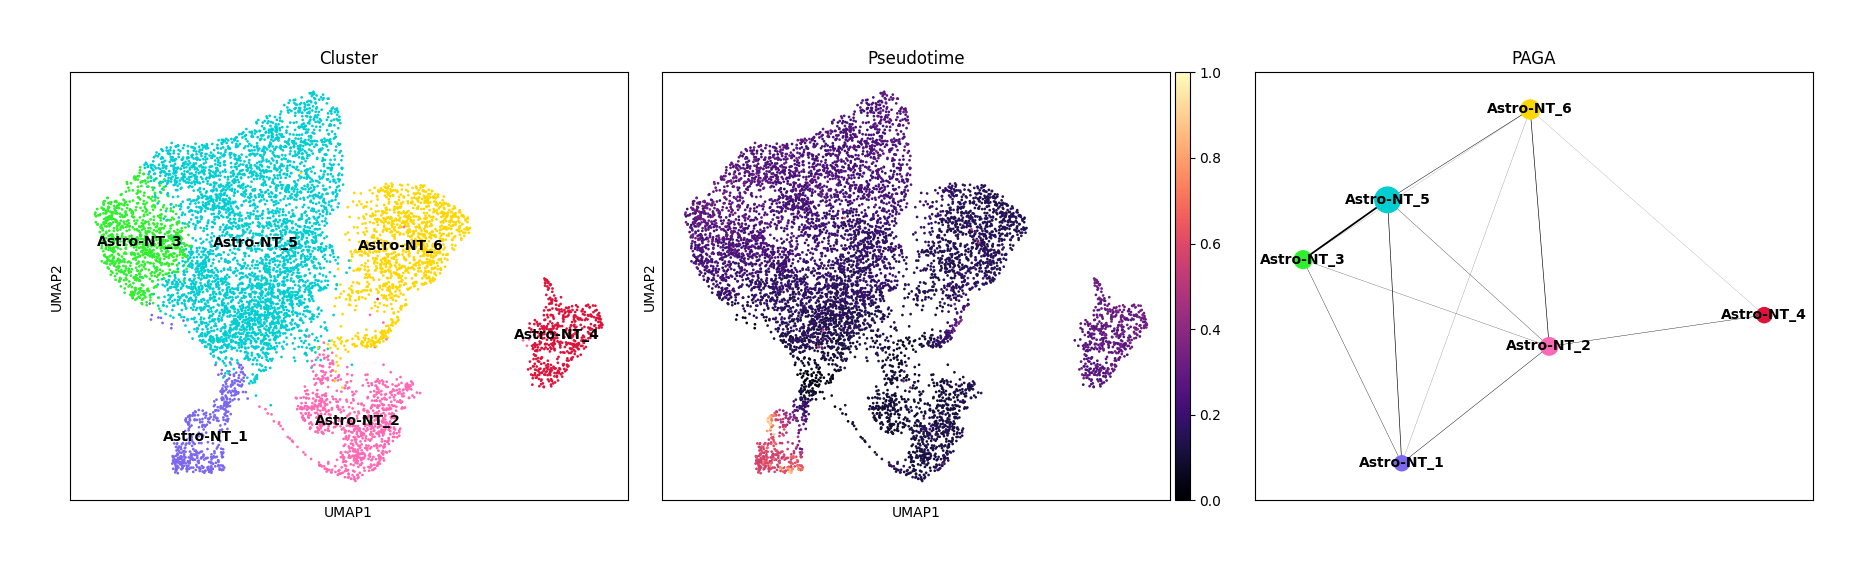

In [ ]:
sc.settings.figdir = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2'

target_batches = [
    'timecourse_1d_2', 'timecourse_1d_3', 'timecourse_1d_8',
    'timecourse_4d_5', 'timecourse_4d_6', 'timecourse_4d_8',
    'timecourse_7d_4', 'timecourse_7d_9',
    'timecourse_14d_10', 'timecourse_14d_8', 'timecourse_14d_9',
    'timecourse_1m_10', 'timecourse_1m_5', 'timecourse_1m_9',
]

# 1. Build subset
astro_sub = astro_adata[astro_adata.obs['batch'].isin(target_batches)].copy()
print(f"Subset: {astro_sub.n_obs} cells")
print(astro_sub.obs['leiden_annotation_simplified'].value_counts())

# 2. Check the available obsm
print("Available obsm:", list(astro_sub.obsm.keys()))

# 3. Recompute neighbors -> UMAP -> PAGA in order
sc.pp.neighbors(astro_sub)  # X_scVI or X_pca (check with obsm.keys)
sc.tl.umap(astro_sub)
sc.tl.paga(astro_sub, groups="leiden_annotation_simplified")

# 4. Set iroot (must be set after computing neighbors)
root_cluster = "Astro-NT_1"

if root_cluster not in astro_sub.obs["leiden_annotation_simplified"].values:
    print(f"WARNING: '{root_cluster}' is not present")
    print("Available:", sorted(astro_sub.obs["leiden_annotation_simplified"].unique().tolist()))
else:
    root_cell_name = astro_sub.obs[
        astro_sub.obs["leiden_annotation_simplified"] == root_cluster
    ].index[0]
    root_index = np.where(astro_sub.obs_names == root_cell_name)[0][0]
    astro_sub.uns['iroot'] = root_index
    print(f"Root cell: {root_cell_name} (index: {root_index})")

    # 5. Compute DPT (after setting iroot)
    sc.tl.dpt(astro_sub)

    # 6. Three-panel plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sc.pl.umap(astro_sub, color="leiden_annotation_simplified",
               title="Cluster", ax=axes[0], show=False, legend_loc="on data")

    sc.pl.umap(astro_sub, color="dpt_pseudotime",
               title="Pseudotime", ax=axes[1], show=False, color_map="magma")

    sc.pl.paga(astro_sub, color="leiden_annotation_simplified",
               title="PAGA", ax=axes[2], show=False)

    plt.tight_layout()
    fig.savefig(f"{sc.settings.figdir}/paga_pseudotime_cluster_injuredOnly_Ver3.svg",
                bbox_inches="tight")
    plt.show()

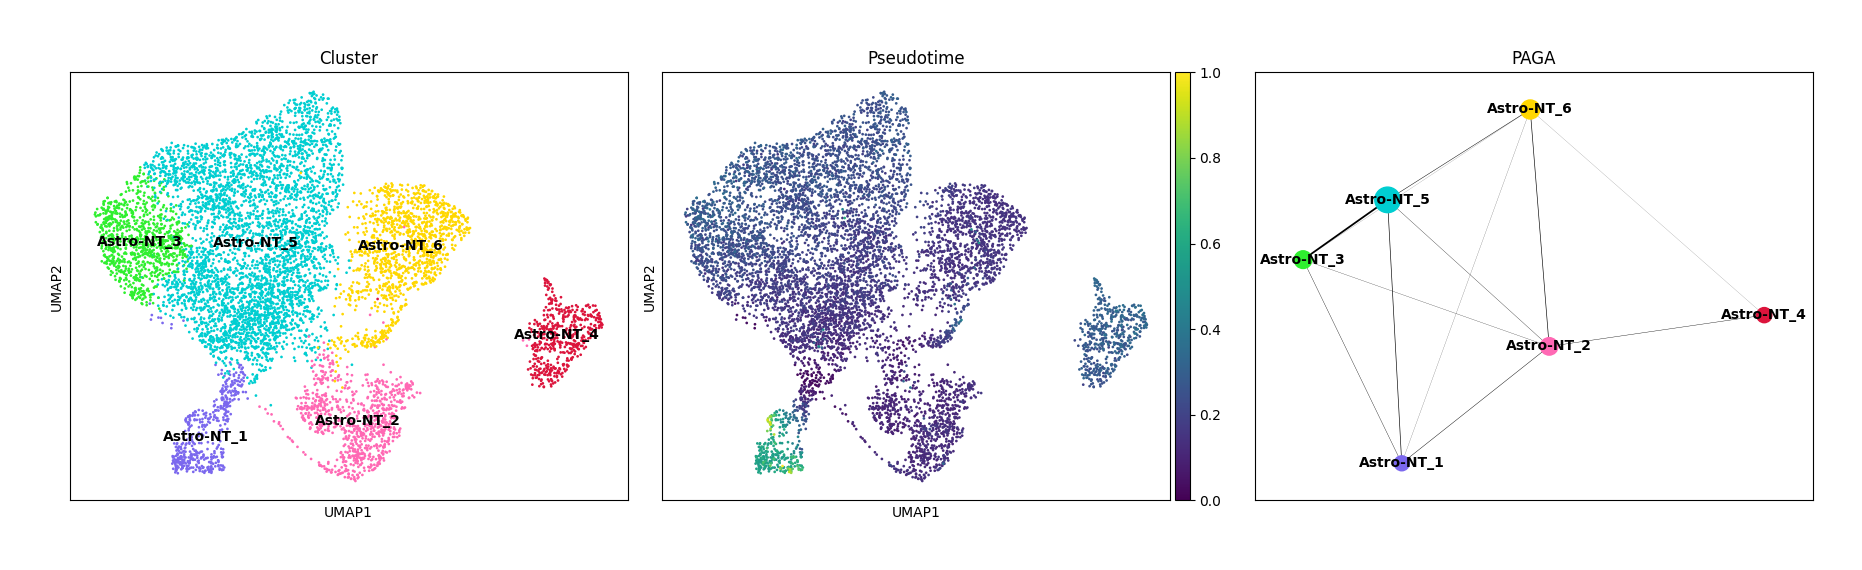

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. UMAP - cluster
sc.pl.umap(
    astro_sub,
    color="leiden_annotation_simplified",
    title="Cluster",
    ax=axes[0],
    show=False,
    legend_loc="on data"
)

# 2. UMAP - pseudotime (clipped)
sc.pl.umap(
    astro_sub,
    color="dpt_pseudotime",
    title="Pseudotime",
    ax=axes[1],
    show=False,
    color_map="viridis",   # <- change this
    vmin=0, vmax=1
)
# Removed the duplicate sc.pl.umap call on axes[1] that was here

# 3. PAGA
sc.pl.paga(
    astro_sub,
    color="leiden_annotation_simplified",
    title="PAGA",
    ax=axes[2],
    show=False
)

plt.tight_layout()
fig.savefig(
    f"{sc.settings.figdir}/paga_pseudotime_cluster_injuredOnly_Ver3.svg",
    bbox_inches="tight"
)
plt.show()

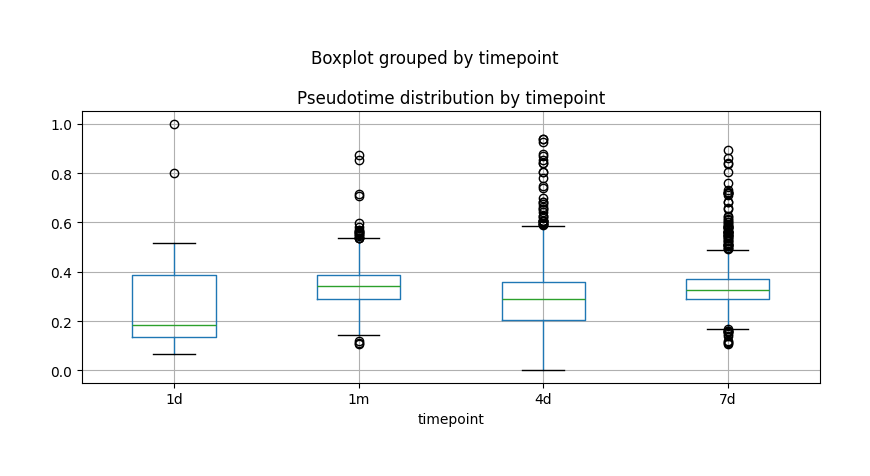

In [ ]:
# Build a timepoint label
def batch_to_timepoint(batch):
    if '1d' in batch: return '1d'
    elif '4d' in batch: return '4d'
    elif '7d' in batch: return '7d'
    elif '14d' in batch: return '14d'
    elif '1m' in batch: return '1m'

astro_sub.obs['timepoint'] = astro_sub.obs['batch'].apply(batch_to_timepoint)

# Check the relationship between pseudotime and timepoint with a box/violin plot
import matplotlib.pyplot as plt

timepoint_order = ['1d', '4d', '7d', '14d', '1m']
fig, ax = plt.subplots(figsize=(8, 4))
astro_sub.obs.boxplot(
    column='dpt_pseudotime',
    by='timepoint',
    ax=ax
)
ax.set_title('Pseudotime distribution by timepoint')
plt.tight_layout()
plt.show()

In [ ]:
print(astro_sub.raw)
print(astro_sub.layers.keys())
print(astro_sub.uns)

Raw AnnData with n_obs × n_vars = 7891 × 25815
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
KeysView(Layers with keys: )
{'diffmap_evals': array([1.        , 0.99989986, 0.99987274, 0.9996895 , 0.99936527,
       0.9991668 , 0.99906003, 0.99885625, 0.99860233, 0.9984812 ,
       0.9981989 , 0.99809843, 0.99807954, 0.9980493 , 0.9977485 ],
      dtype=float32), 'hvg': {'flavor': 'seurat'}, 'leiden': {'modularity': 0.9078175868838089, 'params': {'n_iterations': -1, 'random_state': 0, 'resolution': 1.5}}, 'leiden_annotation_colors': array(['#0000a6', '#d16100', '#ddefff', '#300018', '#c0b9b2', '#c2ff99'],
      dtype=object), 'leiden_annotation_simplified_colors': array(['#00CED1', '#2FEF2F', '#FFD700', '#FF69B4', '#DC143C', '#7B68EE'],
      dtype=object), 'leiden_annotation_simplified_sizes': array([3935,  912, 1221,  868,  489,  466]), 'le

Subset: 7891 cells

--- クラスター分布 ---
leiden_annotation_simplified
Astro-NT_5    3935
Astro-NT_6    1221
Astro-NT_3     912
Astro-NT_2     868
Astro-NT_4     489
Astro-NT_1     466
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



Root cell: timecourse_1d_3-CTCCCAACACAGCATT (index: 2407)

重み付け統合完了 (DPT: 0.5, timepoint: 0.5)


/tmp/ipykernel_15918/2820607331.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
/tmp/ipykernel_15918/2820607331.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


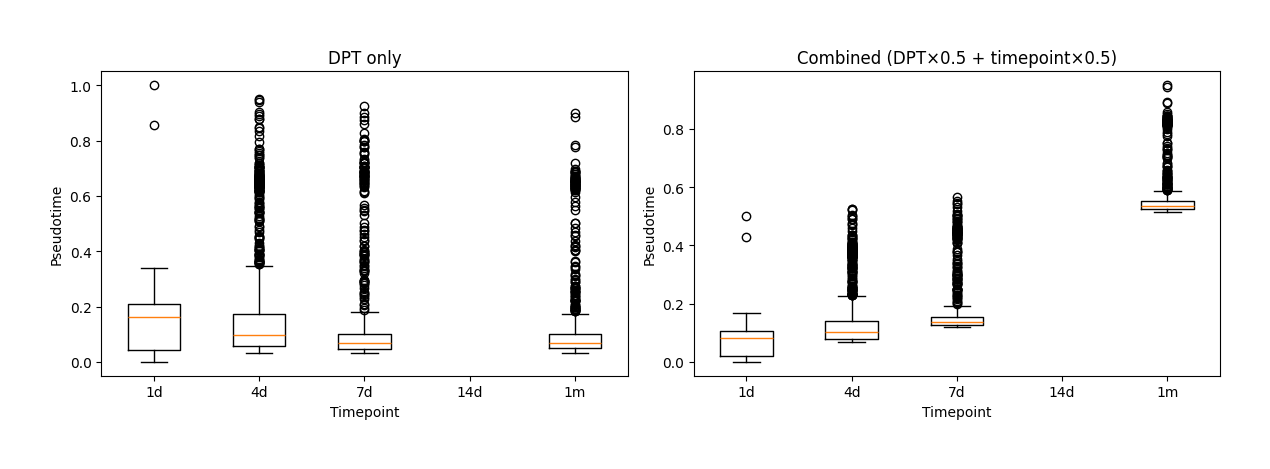

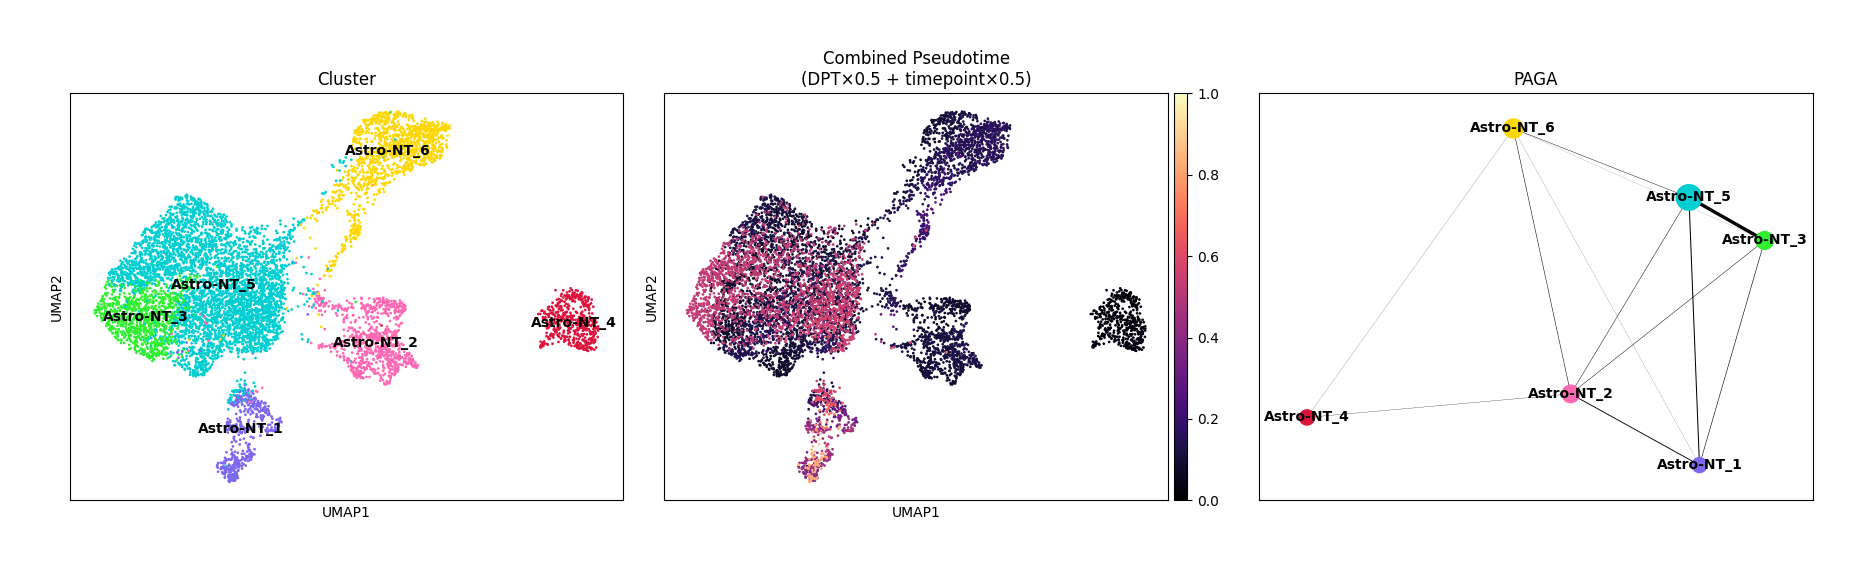

保存完了: /content/drive/MyDrive/scRNA_analysis/figures_Ver2/paga_combinedPseudotime_cluster_injuredOnly_Ver3.svg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Set the output directory
sc.settings.figdir = '/content/drive/MyDrive/scRNA_analysis/figures_Ver2'

# ========== Specify target batches ==========
target_batches = [
    'timecourse_1d_2', 'timecourse_1d_3', 'timecourse_1d_8',
    'timecourse_4d_5', 'timecourse_4d_6', 'timecourse_4d_8',
    'timecourse_7d_4', 'timecourse_7d_9',
    'timecourse_14d_10', 'timecourse_14d_8', 'timecourse_14d_9',
    'timecourse_1m_10', 'timecourse_1m_5', 'timecourse_1m_9',
]

# ========== 1. Build subset ==========
astro_sub = astro_adata[astro_adata.obs['batch'].isin(target_batches)].copy()
astro_sub.uns.pop('iroot', None)

print(f"Subset: {astro_sub.n_obs} cells")
print("\n--- Cluster distribution ---")
print(astro_sub.obs['leiden_annotation_simplified'].value_counts())

# ========== 2. Rerun PCA ==========
sc.pp.scale(astro_sub)
sc.tl.pca(astro_sub, n_comps=30)

# ========== 3. neighbors -> UMAP -> PAGA ==========
sc.pp.neighbors(astro_sub, use_rep="X_pca", n_neighbors=30)
sc.tl.umap(astro_sub)
sc.tl.paga(astro_sub, groups="leiden_annotation_simplified")

# ========== 4. Set iroot -> DPT ==========
root_cluster = "Astro-NT_4"
root_cell_name = astro_sub.obs[
    astro_sub.obs["leiden_annotation_simplified"] == root_cluster
].index[0]
root_index = np.where(astro_sub.obs_names == root_cell_name)[0][0]
astro_sub.uns['iroot'] = root_index
print(f"\nRoot cell: {root_cell_name} (index: {root_index})")

sc.tl.dpt(astro_sub)

# ========== 5. Convert timepoint to a numeric value ==========
def batch_to_timepoint(batch):
    if '1d' in batch: return 1
    elif '4d' in batch: return 4
    elif '7d' in batch: return 7
    elif '14d' in batch: return 14
    elif '1m' in batch: return 30
    else: return np.nan

def batch_to_label(batch):
    if '1d' in batch: return '1d'
    elif '4d' in batch: return '4d'
    elif '7d' in batch: return '7d'
    elif '14d' in batch: return '14d'
    elif '1m' in batch: return '1m'
    else: return 'unknown'

astro_sub.obs['timepoint_numeric'] = astro_sub.obs['batch'].apply(batch_to_timepoint)
astro_sub.obs['timepoint_label'] = astro_sub.obs['batch'].apply(batch_to_label)

# ========== 6. Weighted combination ==========
scaler = MinMaxScaler()
pt = scaler.fit_transform(astro_sub.obs[['dpt_pseudotime']]).flatten()
tp = scaler.fit_transform(astro_sub.obs[['timepoint_numeric']]).flatten()

# Weights are 0.5/0.5; change to (0.3, 0.7) to emphasize timepoint
w_pt, w_tp = 0.5, 0.5
astro_sub.obs['combined_pseudotime'] = w_pt * pt + w_tp * tp

print(f"\nWeighted combination done (DPT: {w_pt}, timepoint: {w_tp})")

# ========== 7. Validation boxplot ==========
timepoint_order = ['1d', '4d', '7d', '14d', '1m']

fig_check, axes_check = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes_check,
    ['dpt_pseudotime', 'combined_pseudotime'],
    ['DPT only', f'Combined (DPT×{w_pt} + timepoint×{w_tp})']
):
    data = [
        astro_sub.obs.loc[astro_sub.obs['timepoint_label'] == tp, col].values
        for tp in timepoint_order
    ]
    ax.boxplot(data, labels=timepoint_order)
    ax.set_title(title)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Pseudotime')

plt.tight_layout()
fig_check.savefig(
    f"{sc.settings.figdir}/pseudotime_validation_boxplot.svg",
    bbox_inches="tight"
)
plt.show()

# ========== 8. Main three-panel plot ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cluster UMAP
sc.pl.umap(
    astro_sub,
    color="leiden_annotation_simplified",
    title="Cluster",
    ax=axes[0],
    show=False,
    legend_loc="on data"
)

# Combined pseudotime UMAP
sc.pl.umap(
    astro_sub,
    color="combined_pseudotime",
    title=f"Combined Pseudotime\n(DPT×{w_pt} + timepoint×{w_tp})",
    ax=axes[1],
    show=False,
    color_map="magma",
    vmin=0, vmax=1
)

# PAGA
sc.pl.paga(
    astro_sub,
    color="leiden_annotation_simplified",
    title="PAGA",
    ax=axes[2],
    show=False,
)

plt.tight_layout()
fig.savefig(
    f"{sc.settings.figdir}/paga_combinedPseudotime_cluster_injuredOnly_Ver3.svg",
    bbox_inches="tight"
)
plt.show()
print(f"Saved: {sc.settings.figdir}/paga_combinedPseudotime_cluster_injuredOnly_Ver3.svg")